<a href="https://colab.research.google.com/github/SnehaGummadi/L1TD1_ORF1p_Binding_Sites_Prediction/blob/main/trained_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Connect to drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

from sklearn.metrics import (roc_auc_score, f1_score,
                              precision_score, recall_score,
                              accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

if torch.backends.mps.is_available():
    torch.set_default_dtype(torch.float32)
    print("Set default to float32 for MPS compatibility")

In [ ]:
def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    elif torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set as {seed}")

set_seed(42)

Random seed set as 42


In [ ]:
DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available()
                      else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## Load Data

In [ ]:
l1td1_seq_df = pd.read_csv("/content/drive/MyDrive/deep_learning_in_genomics/l1td1_seq_df.csv",
               header=0, sep='\t')
l1td1_seq_df.head()

,transcript_sequence,bound
0,ACCGTGAGGGAGGAACAGGATCGCACTCGGGCTGCTGGGAGGCCCC...,1
1,TTTGACCTTCAGCAAGGTCAAAGGGAGTCCGAACTAGTCTCAGGCT...,1
2,GCTGCTCCCGAGTCGGCGCGCGGCGGGGACGCGAGTCCGTAGTTTC...,1
3,GGAGTGAGCGACACAGAGCGGGCCGCCACCGCCGAGCAGCCCTCCG...,1
4,ACTCGCGAGTCCGGCCTGGGCCGCCGGCCCGGCGCGGGCGCCATGA...,1


In [ ]:
l1td1_seq_df.shape

(7314, 2)

In [ ]:
l1td1_seq_df['bound'].value_counts()

,count
bound,
1,4274
0,3040


In [ ]:
# Look at the sequence length distribution
seq_lengths = l1td1_seq_df['transcript_sequence'].apply(len)
seq_lengths.describe().round(2)

,transcript_sequence
count,7314.00
mean,2661.51
std,5472.40
min,69.00
25%,877.00
50%,1614.00
75%,3196.75
max,347561.00


In [ ]:
total = 7314
df = l1td1_seq_df.copy()
over_10k = (df['transcript_sequence'].str.len() > 10000).sum()
print(f"Sequences > 10kb: {over_10k} ({over_10k/total*100:.1f}%)")

# Check if removal is biased toward bound or unbound
df['length'] = df['transcript_sequence'].str.len()
print(df[df['length'] > 10000]['bound'].value_counts())


lengths = df['transcript_sequence'].str.len()
print()
print(lengths[lengths > 50000].describe())
print()
print(df[lengths > 50000]['bound'].value_counts())

Sequences > 10kb: 200 (2.7%)
bound
1    197
0      3
Name: count, dtype: int64

count         3.000000
mean     214746.666667
std      128224.442328
min       91667.000000
25%      148339.500000
50%      205012.000000
75%      276286.500000
max      347561.000000
Name: transcript_sequence, dtype: float64

bound
1    3
Name: count, dtype: int64


In [ ]:
# Check what characters are in the sequences
unique_chars = set()
for seq in df['transcript_sequence']:
  unique_chars.update(seq)
print(f"Unique chars in seqs: {unique_chars}")

Unique chars in seqs: {'G', 'N', 'C', 'T', 'A'}


In [ ]:
# Drop transcripts that have a length greater than 21,000 bps
lengths = df['transcript_sequence'].str.len()
print()
print(lengths[lengths > 21000].describe())
print()
print(df[lengths > 21000]['bound'].value_counts())


count         9.000000
mean      88303.444444
std      114549.924772
min       21103.000000
25%       21777.000000
50%       28227.000000
75%       91667.000000
max      347561.000000
Name: transcript_sequence, dtype: float64

bound
1    9
Name: count, dtype: int64


In [ ]:
df.groupby('bound')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
bound,,,,,,,,
0,3040.0,1369.504605,1025.440567,116.0,707.00,1110.0,1706.00,13327.0
1,4274.0,3580.476603,6962.236351,69.0,1202.25,2455.0,4715.25,347561.0


In [ ]:
# Drop transcripts that have a length greater than 21,000 bps
print(l1td1_seq_df.shape)
l1td1_seq_df = l1td1_seq_df[l1td1_seq_df['transcript_sequence'].str.len() <= 14000]
print(l1td1_seq_df.shape)

(7314, 2)
(7269, 2)


## Encode Data

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def dynamic_pad_collate(batch):
    """Pads a batch of variable-length pre-computed tensors."""
    sequences = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    max_len = max([seq.shape[0] for seq in sequences])

    padded_sequences = []
    for seq in sequences:
        padded = torch.zeros((max_len, 4), dtype=torch.float32)
        padded[:seq.shape[0], :] = seq
        padded_sequences.append(padded)

    return torch.stack(padded_sequences), torch.stack(labels)

In [ ]:
def one_hot_encode(seq):
    """One-hot encode a sequence to its natural length without global padding."""
    allowed = set("ACTGN U")
    if not set(seq).issubset(allowed):
        invalid = set(seq) - allowed
        raise ValueError(f"Invalid characters in sequence: {invalid}")

    nuc_d = {'A': [1.0, 0.0, 0.0, 0.0],
             'C': [0.0, 1.0, 0.0, 0.0],
             'G': [0.0, 0.0, 1.0, 0.0],
             'T': [0.0, 0.0, 0.0, 1.0],
             'N': [0.0, 0.0, 0.0, 0.0]}

    seq_len = len(seq)
    encoded = np.zeros((seq_len, 4), dtype=np.float32)

    for i, base in enumerate(seq):
        encoded[i] = nuc_d[base]

    return encoded

In [ ]:
class SeqDatasetPreloaded(Dataset):
    """
    High-RAM Dataset: Pre-computes and stores all tensors in memory
    during initialization for maximum training speed.
    """
    def __init__(self, df, seq_col='transcript_sequence', label_col='bound'):
        self.samples = []
        self.labels = []

        print(f"Pre-computing one-hot encoding for {len(df)} sequences...")

        # Iterate with a progress bar
        for _, row in tqdm(df.iterrows(), total=len(df)):
            seq = row[seq_col]
            label = row[label_col]

            # Encode to a numpy array, then convert to a PyTorch tensor
            # We store natural lengths, e.g., Tensor of shape (1250, 4)
            encoded_tensor = torch.tensor(one_hot_encode(seq))
            label_tensor = torch.tensor(label, dtype=torch.float32)

            self.samples.append(encoded_tensor)
            self.labels.append(label_tensor)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Instant access; no string processing required!
        return self.samples[idx], self.labels[idx]

In [ ]:
class SeqDatasetPreloadedWithRaw(Dataset):
    """Extended version that also stores raw strings for binding site extraction."""
    def __init__(self, df, seq_col='transcript_sequence', label_col='bound'):
        self.samples = []
        self.labels = []
        self.raw_seqs = []  # <-- store raw strings too

        print(f"Pre-computing one-hot encoding for {len(df)} sequences...")

        for _, row in tqdm(df.iterrows(), total=len(df)):
            seq   = row[seq_col]
            label = row[label_col]

            encoded_tensor = torch.tensor(one_hot_encode(seq))       # (seq_len, 4)
            label_tensor   = torch.tensor(label, dtype=torch.float32)

            self.samples.append(encoded_tensor)
            self.labels.append(label_tensor)
            self.raw_seqs.append(seq)   # <-- keep original string

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx], self.raw_seqs[idx]


def dynamic_pad_collate_with_raw(batch):
    """Pads tensors and passes raw strings through unchanged."""
    sequences = [item[0] for item in batch]
    labels    = [item[1] for item in batch]
    raw_seqs  = [item[2] for item in batch]  # list of strings, no padding needed

    max_len = max(seq.shape[0] for seq in sequences)

    padded_sequences = []
    for seq in sequences:
        padded = torch.zeros((max_len, 4), dtype=torch.float32)
        padded[:seq.shape[0], :] = seq
        padded_sequences.append(padded)

    return torch.stack(padded_sequences), torch.stack(labels), raw_seqs

In [ ]:
def build_dataloaders_preloaded(train_df, val_df, test_df, batch_size=64):

    print("--- Loading Training Set ---")
    train_ds = SeqDatasetPreloaded(train_df)

    print("--- Loading Validation Set ---")
    val_ds   = SeqDatasetPreloaded(val_df)

    print("--- Loading Test Set ---")
    test_ds  = SeqDatasetPreloaded(test_df)

    n_bound = train_df['bound'].sum()
    n_unbound = len(train_df) - n_bound
    print(f"\nTraining set -> Bound: {n_bound}, Unbound: {n_unbound}, Ratio: {n_bound/n_unbound:.2f}")

    class_weights = {0: 1.0 / n_unbound, 1: 1.0 / n_bound}
    sample_weights = [class_weights[label] for label in train_df['bound'].values]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    # Increase num_workers if your CPU has multiple cores.
    # Because there is no string encoding happening, workers just move memory quickly.
    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        collate_fn=dynamic_pad_collate,
        drop_last=True,
        num_workers=4,
        pin_memory=True # Speeds up transfer from RAM to GPU
    )

    val_dl = DataLoader(
        val_ds,
        batch_size=batch_size,
        collate_fn=dynamic_pad_collate,
        num_workers=4,
        pin_memory=True
    )

    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        collate_fn=dynamic_pad_collate,
        num_workers=4,
        pin_memory=True
    )

    return train_dl, val_dl, test_dl

In [ ]:
train_df, test_df = train_test_split(l1td1_seq_df, test_size=0.2, random_state=42)
train_df, val_df  = train_test_split(train_df,  test_size=0.2, random_state=42)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (4652, 2)
Val:   (1163, 2)
Test:  (1454, 2)


## Model

In [ ]:
class RBP_Binary_CNN(nn.Module):
    def __init__(self, num_filters=32, num_filters2=32, num_filters3=32, kernel_size=10):
        super().__init__()
        self.conv    = nn.Conv1d(4, num_filters, kernel_size=kernel_size)
        self.norm    = nn.BatchNorm1d(num_filters)
        self.relu    = nn.GELU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(num_filters, num_filters2, kernel_size=kernel_size)
        self.norm2 = nn.BatchNorm1d(num_filters2)
        self.relu2 = nn.GELU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.drop2 = nn.Dropout1d(0.1)

        self.conv3 = nn.Conv1d(num_filters2, num_filters3, kernel_size=kernel_size)
        self.norm3 = nn.BatchNorm1d(num_filters3)
        self.relu3 = nn.GELU()
        self.drop = nn.Dropout1d(0.5)

        self.globalpool = nn.AdaptiveMaxPool1d(1)
        self.linear  = nn.Linear(num_filters3, 1)

    def forward(self, xb):
        xb = xb.permute(0, 2, 1)   # (batch, seq_len, 4) → (batch, 4, seq_len)
        x = self.pool1(self.relu(self.norm(self.conv(xb))))
        x = self.pool2(self.relu2(self.norm2(self.conv2(x))))
        x = self.drop2(x)
        x = self.relu3(self.norm3(self.conv3(x)))
        x = self.drop(x)
        x = self.globalpool(x).squeeze(-1)
        out = self.linear(x)

        return out

In [ ]:
class EarlyStopping:
    """
    Stops training when val_loss stops improving and saves the best weights.

    Args:
        patience:  how many epochs to wait after last improvement
        min_delta: minimum change to count as an improvement
        path:      where to save the best model checkpoint
    """
    def __init__(self, patience=10, min_delta=1e-4, path='best_model.pt'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path

        self.best_loss  = np.inf
        self.counter    = 0        # epochs without improvement
        self.best_epoch = 0
        self.stop       = False    # flag the training loop reads

    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            # Improvement — save weights and reset counter
            self.best_loss  = val_loss
            self.best_epoch = epoch
            self.counter    = 0
            torch.save(model.state_dict(), self.path)
            print(f"  ✓ New best val_loss: {val_loss:.4f} — checkpoint saved")
        else:
            # No improvement
            self.counter += 1
            print(f"  ✗ No improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stop = True

    def load_best_weights(self, model):
        """Call after training to restore the best checkpoint."""
        model.load_state_dict(torch.load(self.path))
        print(f"  Restored best weights from epoch {self.best_epoch}")

In [ ]:
def train_model(model, train_dl, val_dl, device, lr=0.01, epochs=50,
                optimizer_cls=torch.optim.SGD,
                scheduler_patience=5, scheduler_factor=0.5, scheduler_min_lr=1e-6,
                # --- early stopping params ---
                es_patience=10, es_min_delta=1e-4, checkpoint_path='best_model.pt'):

    optimizer = optimizer_cls(model.parameters(), lr=lr, weight_decay=1e-4)
    if optimizer_cls == torch.optim.SGD:
      optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95, nesterov=True)

    loss_fn   = nn.BCEWithLogitsLoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor,
        patience=scheduler_patience, min_lr=scheduler_min_lr
    )

    early_stopping = EarlyStopping(
        patience=es_patience,
        min_delta=es_min_delta,
        path=checkpoint_path
    )

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        batch_losses, batch_sizes = [], []
        all_train_preds, all_train_labels = [], []

        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb.float()).squeeze(-1)
            loss   = loss_fn(logits, yb.float())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            batch_sizes.append(len(xb))
            preds = (torch.sigmoid(logits) >= 0.5).long()
            all_train_preds.append(preds.cpu())
            all_train_labels.append(yb.long().cpu())

        train_loss = np.average(batch_losses, weights=batch_sizes)
        train_losses.append(train_loss)
        train_acc  = (torch.cat(all_train_preds).numpy() ==
                      torch.cat(all_train_labels).numpy()).mean()

        # --- Validation ---
        model.eval()
        vl, ns = [], []
        all_val_preds, all_val_labels = [], []

        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb.float()).squeeze(-1)
                loss   = loss_fn(logits, yb.float())
                vl.append(loss.item())
                ns.append(len(xb))
                preds = (torch.sigmoid(logits) >= 0.5).long()
                all_val_preds.append(preds.cpu())
                all_val_labels.append(yb.long().cpu())

        val_loss = np.average(vl, weights=ns)
        val_losses.append(val_loss)
        val_acc  = (torch.cat(all_val_preds).numpy() ==
                    torch.cat(all_val_labels).numpy()).mean()

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"E{epoch+1:03d} | "
              f"train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
              f"val loss: {val_loss:.4f}  acc: {val_acc:.4f} | "
              f"lr: {current_lr:.2e}")

        # --- Early stopping check (after scheduler, at end of epoch) ---
        early_stopping.step(val_loss, model, epoch + 1)
        if early_stopping.stop:
            print(f"\nEarly stopping at epoch {epoch + 1}. "
                  f"Best val_loss: {early_stopping.best_loss:.4f} "
                  f"at epoch {early_stopping.best_epoch}")
            break

    # Restore the best weights before returning
    early_stopping.load_best_weights(model)

    return train_losses, val_losses

In [ ]:
def test_model(model, test_dl, device):
    """Evaluate binary classifier on test set and log metrics to W&B."""
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for xb, yb in test_dl:
            xb = xb.to(device)
            logits = model(xb.float()).squeeze(-1)   # raw logits, shape (batch,)
            all_logits.append(logits.cpu())
            all_labels.append(yb)

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()

    probs = 1 / (1 + np.exp(-logits))       # sigmoid → probabilities
    preds = (probs >= 0.5).astype(int)       # hard predictions

    metrics = {
        'test_accuracy':  accuracy_score(labels, preds),
        'test_auroc':     roc_auc_score(labels, probs),      # uses probabilities, not hard preds
        'test_f1':        f1_score(labels, preds),
        'test_precision': precision_score(labels, preds),
        'test_recall':    recall_score(labels, preds),
    }

    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()

    print("\n=== Test Results ===")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    print(f"  Confusion matrix → TN:{tn}  FP:{fp}  FN:{fn}  TP:{tp}")

    return probs, preds, labels, metrics

## Model Training + Testing

In [ ]:
train_dl, val_dl, test_dl = build_dataloaders_preloaded(train_df, val_df, test_df)

--- Loading Training Set ---
Pre-computing one-hot encoding for 4652 sequences...


100%|██████████| 4652/4652 [00:08<00:00, 547.36it/s]


--- Loading Validation Set ---
Pre-computing one-hot encoding for 1163 sequences...


100%|██████████| 1163/1163 [00:01<00:00, 694.72it/s]


--- Loading Test Set ---
Pre-computing one-hot encoding for 1454 sequences...


100%|██████████| 1454/1454 [00:01<00:00, 740.88it/s]


Training set -> Bound: 2692, Unbound: 1960, Ratio: 1.37



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
model = RBP_Binary_CNN(num_filters=32,
                        num_filters2=32,
                        kernel_size=15
                        ).to(DEVICE)

print("Training started...")

train_model(model, train_dl, val_dl, DEVICE, lr=0.001,
            epochs=50, optimizer_cls=torch.optim.SGD
            )

test_model(model, test_dl, DEVICE)

Training started...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


E001 | train loss: 0.8167  acc: 0.5106 | val loss: 0.6683  acc: 0.5950 | lr: 1.00e-03
  ✓ New best val_loss: 0.6683 — checkpoint saved
E002 | train loss: 0.6728  acc: 0.5738 | val loss: 0.6063  acc: 0.6879 | lr: 1.00e-03
  ✓ New best val_loss: 0.6063 — checkpoint saved
E003 | train loss: 0.6468  acc: 0.6170 | val loss: 0.5958  acc: 0.7291 | lr: 1.00e-03
  ✓ New best val_loss: 0.5958 — checkpoint saved
E004 | train loss: 0.6370  acc: 0.6376 | val loss: 0.5733  acc: 0.7343 | lr: 1.00e-03
  ✓ New best val_loss: 0.5733 — checkpoint saved
E005 | train loss: 0.6313  acc: 0.6630 | val loss: 0.6049  acc: 0.7034 | lr: 1.00e-03
  ✗ No improvement (1/10)
E006 | train loss: 0.6082  acc: 0.6868 | val loss: 0.5647  acc: 0.7300 | lr: 1.00e-03
  ✓ New best val_loss: 0.5647 — checkpoint saved
E007 | train loss: 0.6082  acc: 0.6882 | val loss: 0.5668  acc: 0.7283 | lr: 1.00e-03
  ✗ No improvement (1/10)
E008 | train loss: 0.6013  acc: 0.6984 | val loss: 0.5708  acc: 0.7257 | lr: 1.00e-03
  ✗ No improvem

(array([0.83476096, 0.34128368, 0.28822926, ..., 0.8986049 , 0.3192291 ,
        0.9933334 ], dtype=float32),
 array([1, 0, 0, ..., 1, 0, 1]),
 array([0., 0., 0., ..., 1., 0., 1.], dtype=float32),
 {'test_accuracy': 0.7558459422283357,
  'test_auroc': np.float64(0.8150931593501354),
  'test_f1': 0.7708198837959974,
  'test_precision': 0.8553008595988538,
  'test_recall': 0.7015276145710928})

In [ ]:
# Test Model
model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(DEVICE)
        logits = model(xb.float()).squeeze(-1)   # raw logits, shape (batch,)
        all_logits.append(logits.cpu())
        all_labels.append(yb)

logits = torch.cat(all_logits).numpy()
labels = torch.cat(all_labels).numpy()

probs = 1 / (1 + np.exp(-logits))       # sigmoid → probabilities
preds = (probs >= 0.5).astype(int)       # hard predictions

metrics = {
    'test_accuracy':  accuracy_score(labels, preds),
    'test_auroc':     roc_auc_score(labels, probs),      # uses probabilities, not hard preds
    'test_f1':        f1_score(labels, preds),
    'test_precision': precision_score(labels, preds),
    'test_recall':    recall_score(labels, preds),
}

cm = confusion_matrix(labels, preds)
tn, fp, fn, tp = cm.ravel()

print("\n=== Test Results ===")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"  Confusion matrix → TN:{tn}  FP:{fp}  FN:{fn}  TP:{tp}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



=== Test Results ===
  test_accuracy: 0.7558
  test_auroc: 0.8151
  test_f1: 0.7708
  test_precision: 0.8553
  test_recall: 0.7015
  Confusion matrix → TN:502  FP:101  FN:254  TP:597


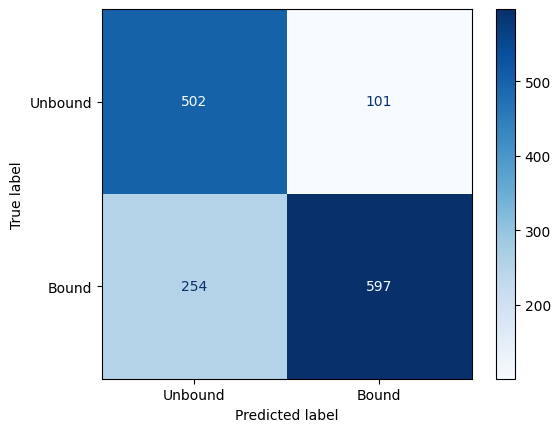

In [ ]:
# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unbound', 'Bound'],  )
disp.plot(cmap=plt.cm.Blues)

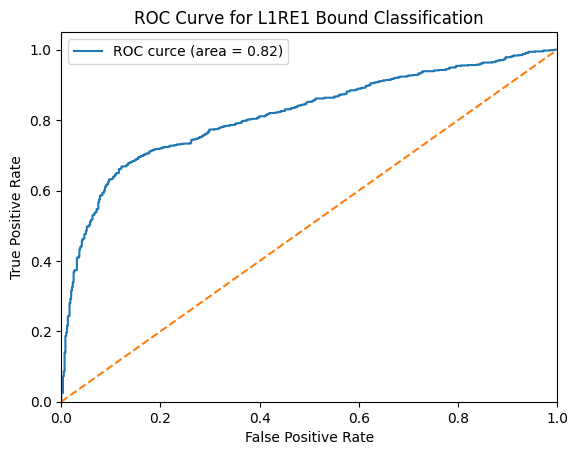

In [ ]:
fpr, tpr, thresholds = roc_curve(labels, probs)
plt.plot(fpr, tpr, label='ROC curce (area = %0.2f)'%metrics['test_auroc'])
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for L1RE1 Bound Classification')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend()
plt.show()

## Extract filters

In [ ]:
!pip install logomaker -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 38.7 MB/s eta 0:00:00


In [ ]:
def build_extraction_dataloader(test_df, batch_size=64):
    """Separate loader for binding site extraction — no sampler needed, just ordered."""
    test_ds = SeqDatasetPreloadedWithRaw(test_df)

    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,           # keep order for reproducibility
        collate_fn=dynamic_pad_collate_with_raw,
        num_workers=4,
        pin_memory=True
    )
    return test_dl

extraction_dl = build_extraction_dataloader(test_df)

Pre-computing one-hot encoding for 1454 sequences...


100%|██████████| 1454/1454 [00:02<00:00, 489.63it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
activations = {}

def get_activation_hook(layer_name):
    def hook(module, input, output):
        # output shape: (batch, num_filters, L)
        activations[layer_name] = output.detach().cpu()
    return hook

# Adjust attribute names to match your model
model.conv.register_forward_hook(get_activation_hook('conv'))
model.conv2.register_forward_hook(get_activation_hook('conv2'))
model.conv3.register_forward_hook(get_activation_hook('conv3'))

In [ ]:
from collections import defaultdict

# Map layer name -> kernel size (set these to your actual values)
layer_kernel_sizes = {
    'conv': 15,
    'conv2': 15,
    'conv3': 15,
}

# Optionally split binders/non-binders
# True = all sequences, or filter test_df beforehand
max_activation_seqs = {layer: defaultdict(list) for layer in layer_kernel_sizes}
model.eval()

with torch.no_grad():
    for batch_onehot, batch_labels, batch_raw in extraction_dl:

        # batch_onehot shape: (batch, max_len, 4)
        # DO NOT permute here — the model's forward() already does it
        batch_onehot = batch_onehot.to(DEVICE)  # (B, seq_len, 4)

        _ = model(batch_onehot)  # triggers all hooks

        for layer_name, kernel_size in layer_kernel_sizes.items():
            act = activations[layer_name]   # (B, num_filters, L)

            for b in range(act.shape[0]):
                raw_seq  = batch_raw[b]
                true_len = len(raw_seq)

                for f in range(act.shape[1]):
                    filter_act = act[b, f, :]

                    valid_len = true_len - kernel_size + 1
                    if valid_len <= 0:
                        continue
                    filter_act_valid = filter_act[:valid_len]

                    max_pos = filter_act_valid.argmax().item()
                    max_val = filter_act_valid[max_pos].item()

                    subseq = raw_seq[max_pos : max_pos + kernel_size]
                    if len(subseq) == kernel_size:
                        max_activation_seqs[layer_name][f].append((max_val, subseq))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
def extract_top_binding_sites(max_activation_seqs, top_n=50):
    binding_site_dict = {}

    for layer_name, filters in max_activation_seqs.items():
        for f_idx, seq_val_pairs in filters.items():
            sorted_seqs = sorted(seq_val_pairs, key=lambda x: x[0], reverse=True)
            top_seqs    = [s for _, s in sorted_seqs[:top_n]]
            binding_site_dict[f"{layer_name}_filter_{f_idx}"] = top_seqs

    return binding_site_dict

binding_site_dict    = extract_top_binding_sites(max_activation_seqs, top_n=50)
all_sequences = [seq for seqs in binding_site_dict.values() for seq in seqs]

print(f"Total extracted sequences: {len(all_sequences)}")
print("Example:", all_sequences[:5])

Total extracted sequences: 4800
Example: ['AAGTCAGGATATGTG', 'GAGACAGGATAAAGG', 'GAGACGGAATAAATG', 'GAGACATGATATAGG', 'AAGACAGGATAAATG']


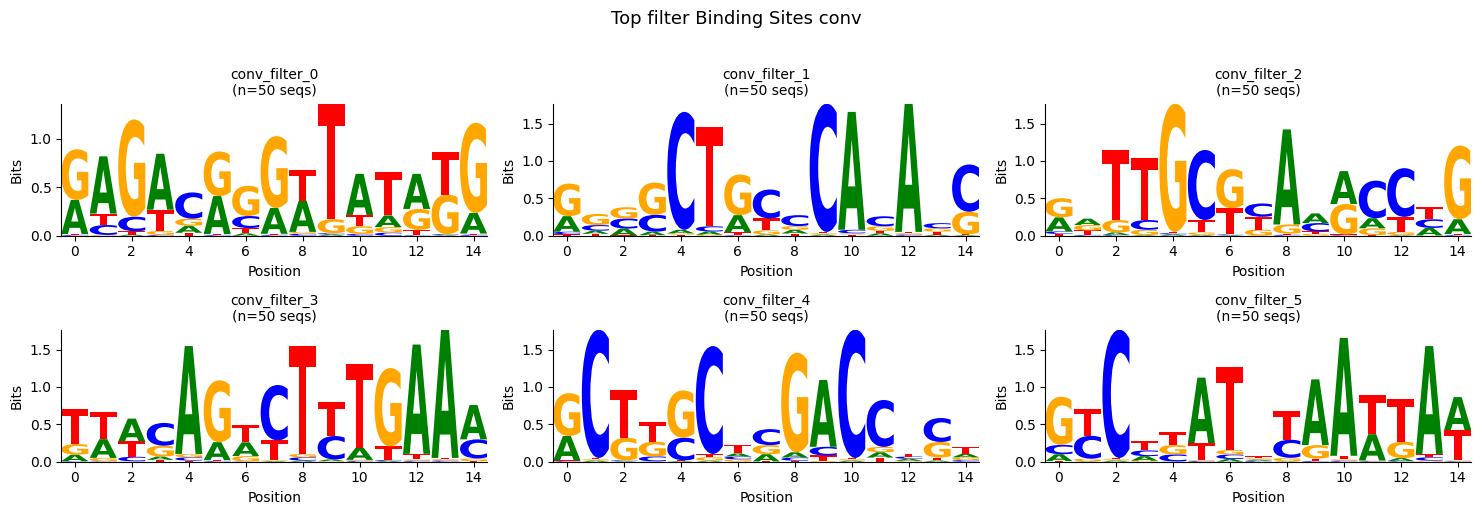

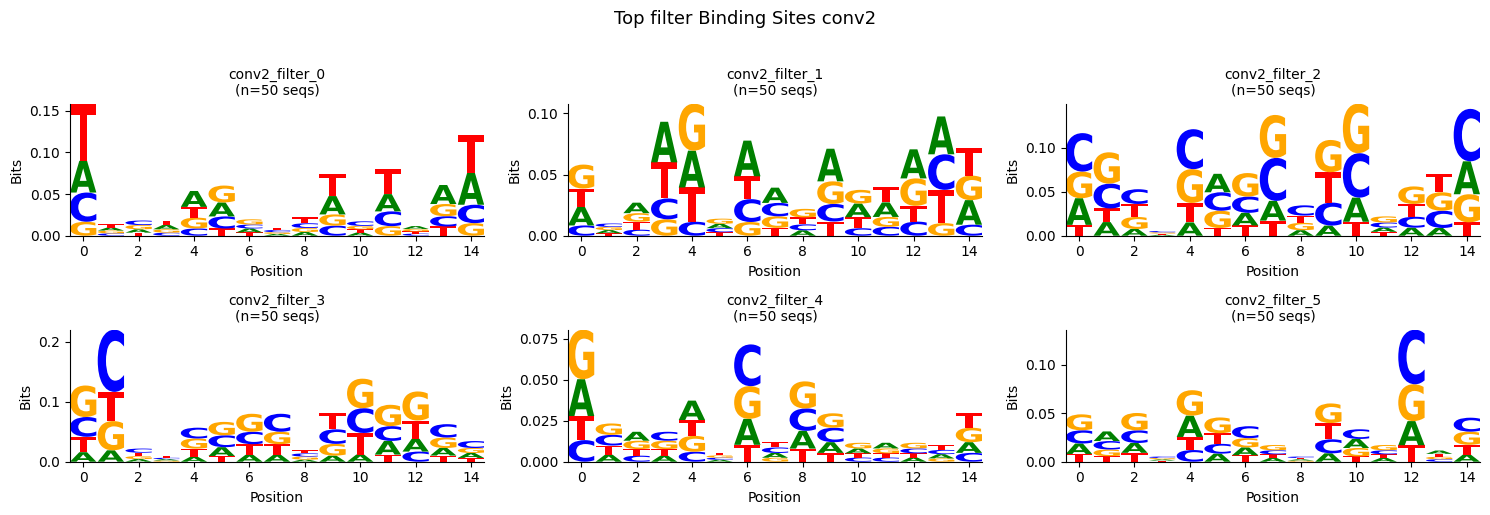

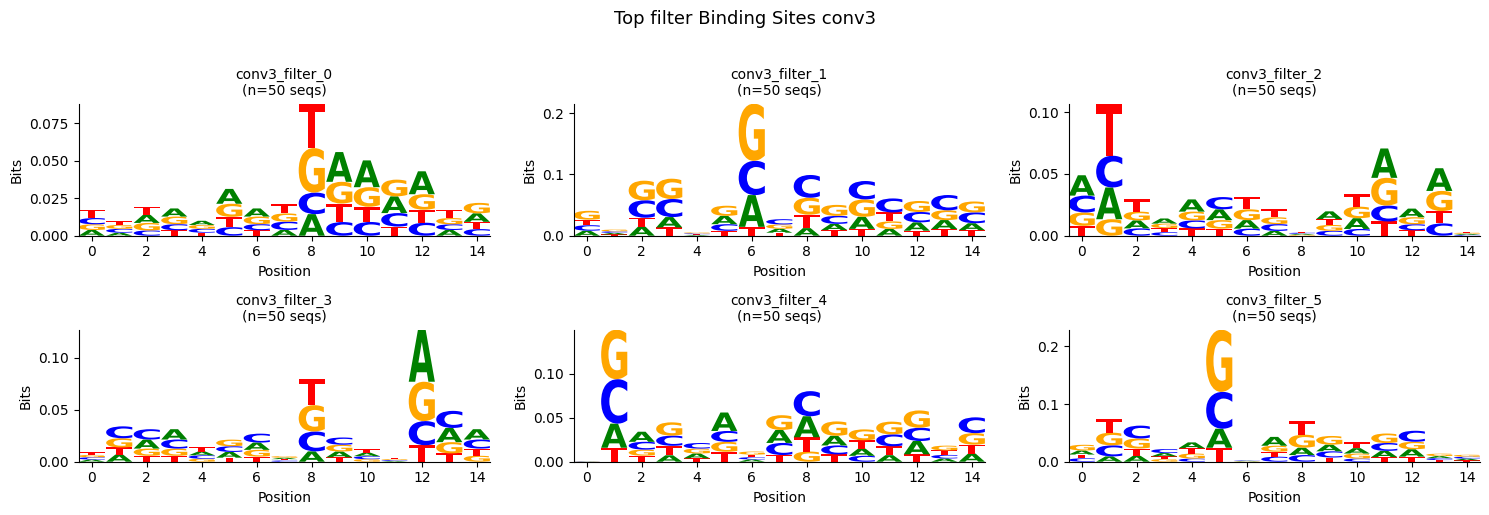

In [ ]:
import logomaker

def seqs_to_pfm(sequences):
    """Convert a list of same-length sequences to a Position Frequency Matrix."""
    bases = ['A', 'C', 'G', 'T']
    length = len(sequences[0])

    pfm = pd.DataFrame(0.0, index=range(length), columns=bases)

    for seq in sequences:
        for i, base in enumerate(seq):
            if base in bases:
                pfm.loc[i, base] += 1

    return pfm

def pfm_to_ppm(pfm, pseudocount=0.5):
    """Convert frequency matrix to probability matrix with pseudocount."""
    ppm = pfm + pseudocount
    ppm = ppm.div(ppm.sum(axis=1), axis=0)
    return ppm

def plot_filter_logos(binding_site_dict, layer_name='conv1', n_filters=6, top_n=50):
    """
    Plot sequence logos for the top n_filters filters in a given layer.

    Args:
        binding_site_dict:  output of extract_top_binding_sites()
        layer_name:  which layer to visualise ('conv', 'conv2', 'conv3')
        n_filters:   how many filters to plot
        top_n:       how many top sequences to use per filter
    """
    # Pull only keys for the requested layer
    layer_keys = [k for k in binding_site_dict if k.startswith(layer_name)][:n_filters]

    n_cols = 3
    n_rows = -(-len(layer_keys) // n_cols)  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 5, n_rows * 2.5))
    axes = axes.flatten()

    for ax, key in zip(axes, layer_keys):
        seqs = binding_site_dict[key][:top_n]

        if len(seqs) < 5:
            ax.set_visible(False)
            continue

        pfm = seqs_to_pfm(seqs)
        ppm = pfm_to_ppm(pfm)

        # Convert to information-content logo (bits)
        logo = logomaker.transform_matrix(ppm, from_type='probability',
                                          to_type='information')

        logomaker.Logo(logo, ax=ax, color_scheme='classic')

        ax.set_title(f"{key}\n(n={len(seqs)} seqs)", fontsize=10)
        ax.set_xlabel("Position")
        ax.set_ylabel("Bits")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Hide any unused subplots
    for ax in axes[len(layer_keys):]:
        ax.set_visible(False)

    plt.suptitle(f"Top filter Binding Sites {layer_name}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# --- Usage ---

# Plot 6 filters from each layer
plot_filter_logos(binding_site_dict, layer_name='conv', n_filters=6, top_n=50)
plot_filter_logos(binding_site_dict, layer_name='conv2', n_filters=6, top_n=50)
plot_filter_logos(binding_site_dict, layer_name='conv3', n_filters=6, top_n=50)

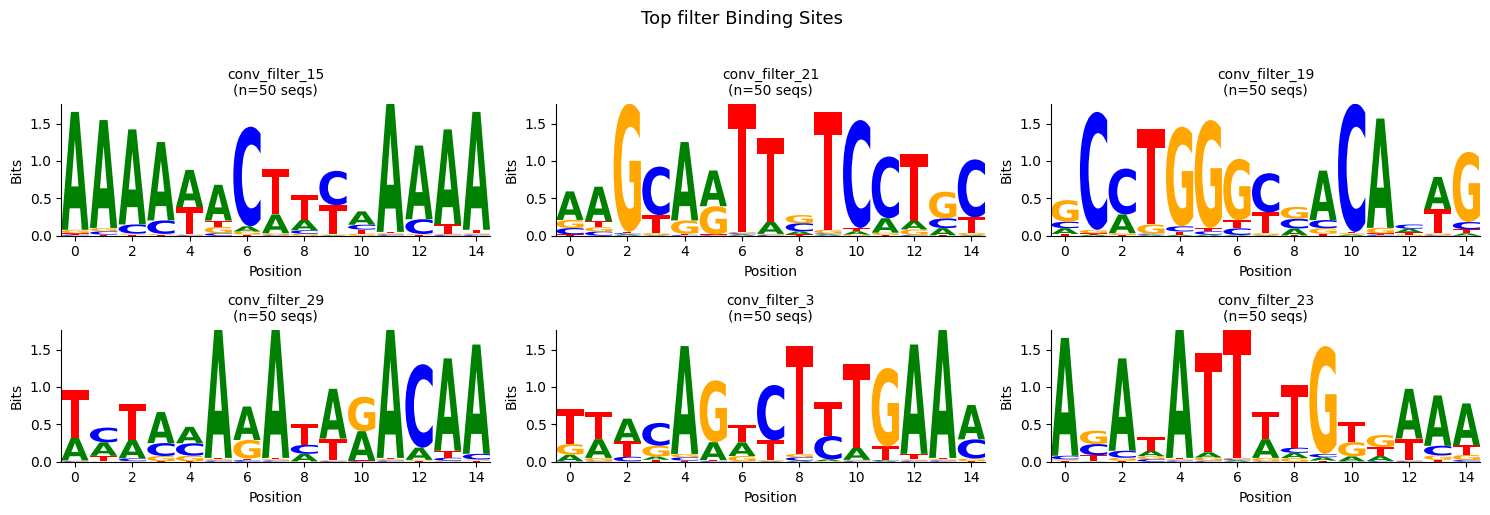

In [ ]:
def get_total_information(seqs):
    """Total bits of information in a binding sites — higher = more specific."""
    if len(seqs) < 5:
        return 0.0
    pfm = seqs_to_pfm(seqs)
    ppm = pfm_to_ppm(pfm)
    ic  = logomaker.transform_matrix(ppm, from_type='probability', to_type='information')
    return ic.values.sum()

# Rank all filters by information content and plot the top 6
ranked = sorted(binding_site_dict.items(),
                key=lambda x: get_total_information(x[1]),
                reverse=True)

top_informative = dict(ranked[:6])
plot_filter_logos(top_informative, layer_name='', n_filters=6, top_n=50)

## Compare Extracted Binding Sequences with CLIP-seq

## Train Model on ORF1p RIP-seq Data

In [ ]:
orf1_seq_df = pd.read_csv("/content/drive/MyDrive/deep_learning_in_genomics/orf1_seq_df.csv",
               header=0, sep='\t')
orf1_seq_df.head()

,transcript_sequence,bound
0,GGGGCCGGAAGTGGGGTGCACGCTTCGGGTTGGTGTCATGGCAGCT...,1
1,GGCATTCTGGGGCCGGAAGTGGGGTGCACGCTTCGGGTTGGTGTCA...,1
2,AGGGGCCCGCCGCGCCCATCCCGATGGCTGGAGGCGTCTGAGGGGC...,1
3,CTGCAGGCGGGGCGGTGTCGGCGGCCGGAGCCCCCGCGCGGGCCGC...,1
4,AGGCGGGGCGGTGTCGGCGGCCGGAGCCCCCGCGCGGGCCGCCTAT...,1


In [ ]:
# Remove sequences with a length greater than 14000
orf1_seq_df = orf1_seq_df[orf1_seq_df['transcript_sequence'].str.len() <= 14000]
orf1_seq_df.shape

(8783, 2)

In [ ]:
train_df, test_df = train_test_split(orf1_seq_df, test_size=0.2, random_state=42)
train_df, val_df  = train_test_split(train_df,  test_size=0.2, random_state=42)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (5620, 2)
Val:   (1406, 2)
Test:  (1757, 2)


In [ ]:
train_dl, val_dl, test_dl = build_dataloaders_preloaded(train_df, val_df, test_df)

--- Loading Training Set ---
Pre-computing one-hot encoding for 5620 sequences...


100%|██████████| 5620/5620 [00:10<00:00, 543.76it/s]


--- Loading Validation Set ---
Pre-computing one-hot encoding for 1406 sequences...


100%|██████████| 1406/1406 [00:02<00:00, 539.30it/s]


--- Loading Test Set ---
Pre-computing one-hot encoding for 1757 sequences...


100%|██████████| 1757/1757 [00:02<00:00, 640.07it/s]


Training set -> Bound: 1615, Unbound: 4005, Ratio: 0.40



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
model = RBP_Binary_CNN(num_filters=32,
                        num_filters2=32,
                        kernel_size=15
                        ).to(DEVICE)

train_model(model, train_dl, val_dl, DEVICE, lr=0.001,
            epochs=50, optimizer_cls=torch.optim.SGD
            )

test_model(model, test_dl, DEVICE)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


E001 | train loss: 0.7758  acc: 0.4872 | val loss: 0.6802  acc: 0.6856 | lr: 1.00e-03
  ✓ New best val_loss: 0.6802 — checkpoint saved
E002 | train loss: 0.6962  acc: 0.5133 | val loss: 0.6982  acc: 0.3151 | lr: 1.00e-03
  ✗ No improvement (1/10)
E003 | train loss: 0.6968  acc: 0.5081 | val loss: 0.7286  acc: 0.3144 | lr: 1.00e-03
  ✗ No improvement (2/10)
E004 | train loss: 0.6960  acc: 0.5056 | val loss: 0.6987  acc: 0.4424 | lr: 1.00e-03
  ✗ No improvement (3/10)
E005 | train loss: 0.6928  acc: 0.5192 | val loss: 0.6957  acc: 0.4509 | lr: 1.00e-03
  ✗ No improvement (4/10)
E006 | train loss: 0.6908  acc: 0.5329 | val loss: 0.6792  acc: 0.6757 | lr: 1.00e-03
  ✓ New best val_loss: 0.6792 — checkpoint saved
E007 | train loss: 0.6896  acc: 0.5280 | val loss: 0.6811  acc: 0.5903 | lr: 1.00e-03
  ✗ No improvement (1/10)
E008 | train loss: 0.6884  acc: 0.5359 | val loss: 0.6806  acc: 0.5846 | lr: 1.00e-03
  ✗ No improvement (2/10)
E009 | train loss: 0.6832  acc: 0.5544 | val loss: 0.6839 

(array([0.397504  , 0.44902313, 0.6335557 , ..., 0.47078806, 0.32790515,
        0.4137386 ], dtype=float32),
 array([0, 0, 1, ..., 0, 0, 0]),
 array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 {'test_accuracy': 0.749003984063745,
  'test_auroc': np.float64(0.7768732316674465),
  'test_f1': 0.5803996194100857,
  'test_precision': 0.5776515151515151,
  'test_recall': 0.5831739961759083})

In [ ]:
# Test Model
model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(DEVICE)
        logits = model(xb.float()).squeeze(-1)   # raw logits, shape (batch,)
        all_logits.append(logits.cpu())
        all_labels.append(yb)

logits = torch.cat(all_logits).numpy()
labels = torch.cat(all_labels).numpy()

probs = 1 / (1 + np.exp(-logits))       # sigmoid → probabilities
preds = (probs >= 0.5).astype(int)       # hard predictions

metrics = {
    'test_accuracy':  accuracy_score(labels, preds),
    'test_auroc':     roc_auc_score(labels, probs),      # uses probabilities, not hard preds
    'test_f1':        f1_score(labels, preds),
    'test_precision': precision_score(labels, preds),
    'test_recall':    recall_score(labels, preds),
}

cm = confusion_matrix(labels, preds)
tn, fp, fn, tp = cm.ravel()

print("\n=== Test Results ===")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"  Confusion matrix → TN:{tn}  FP:{fp}  FN:{fn}  TP:{tp}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



=== Test Results ===
  test_accuracy: 0.7490
  test_auroc: 0.7769
  test_f1: 0.5804
  test_precision: 0.5777
  test_recall: 0.5832
  Confusion matrix → TN:1011  FP:223  FN:218  TP:305


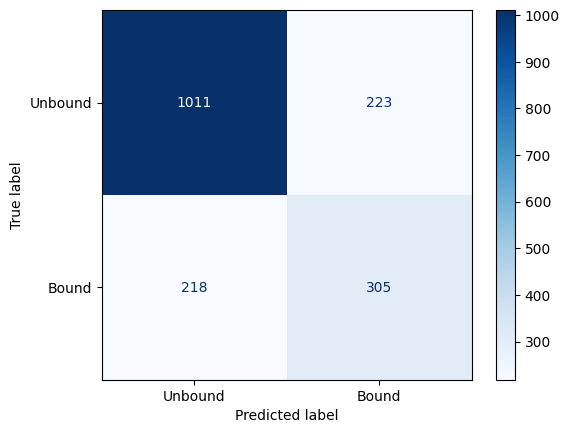

In [ ]:
# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unbound', 'Bound'],  )
disp.plot(cmap=plt.cm.Blues)

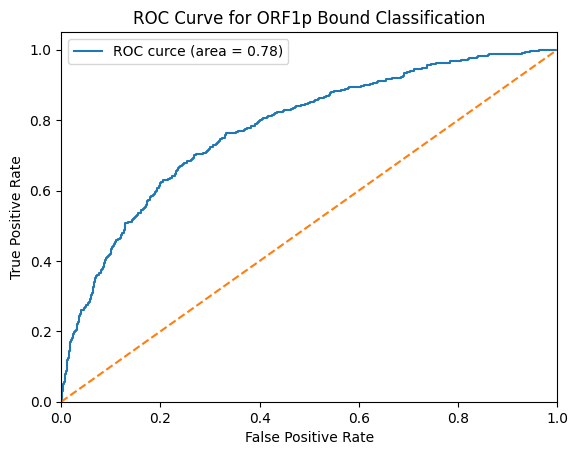

In [ ]:
fpr, tpr, thresholds = roc_curve(labels, probs)
plt.plot(fpr, tpr, label='ROC curce (area = %0.2f)'%metrics['test_auroc'])
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ORF1p Bound Classification')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend()
plt.show()

In [ ]:
extraction_dl = build_extraction_dataloader(test_df)

Pre-computing one-hot encoding for 1757 sequences...


100%|██████████| 1757/1757 [00:03<00:00, 475.43it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
activations = {}

def get_activation_hook(layer_name):
    def hook(module, input, output):
        # output shape: (batch, num_filters, L)
        activations[layer_name] = output.detach().cpu()
    return hook

# Adjust attribute names to match your model
model.conv.register_forward_hook(get_activation_hook('conv'))
model.conv2.register_forward_hook(get_activation_hook('conv2'))
model.conv3.register_forward_hook(get_activation_hook('conv3'))

In [ ]:
# Map layer name -> kernel size (set these to your actual values)
layer_kernel_sizes = {
    'conv': 15,
    'conv2': 15,
    'conv3': 15,
}

# Optionally split binders/non-binders
# True = all sequences, or filter test_df beforehand
max_activation_seqs = {layer: defaultdict(list) for layer in layer_kernel_sizes}
model.eval()

with torch.no_grad():
    for batch_onehot, batch_labels, batch_raw in extraction_dl:

        # batch_onehot shape: (batch, max_len, 4)
        # DO NOT permute here — the model's forward() already does it
        batch_onehot = batch_onehot.to(DEVICE)  # (B, seq_len, 4)

        _ = model(batch_onehot)  # triggers all hooks

        for layer_name, kernel_size in layer_kernel_sizes.items():
            act = activations[layer_name]   # (B, num_filters, L)

            for b in range(act.shape[0]):
                raw_seq  = batch_raw[b]
                true_len = len(raw_seq)

                for f in range(act.shape[1]):
                    filter_act = act[b, f, :]

                    valid_len = true_len - kernel_size + 1
                    if valid_len <= 0:
                        continue
                    filter_act_valid = filter_act[:valid_len]

                    max_pos = filter_act_valid.argmax().item()
                    max_val = filter_act_valid[max_pos].item()

                    subseq = raw_seq[max_pos : max_pos + kernel_size]
                    if len(subseq) == kernel_size:
                        max_activation_seqs[layer_name][f].append((max_val, subseq))

In [ ]:
binding_site_dict_o    = extract_top_binding_sites(max_activation_seqs, top_n=50)
all_sequences_o = [seq for seqs in binding_site_dict.values() for seq in seqs]

print(f"Total extracted sequences: {len(all_sequences_o)}")
print("Example:", all_sequences_o[:5])

Total extracted sequences: 4800
Example: ['AAGTCAGGATATGTG', 'GAGACAGGATAAAGG', 'GAGACGGAATAAATG', 'GAGACATGATATAGG', 'AAGACAGGATAAATG']


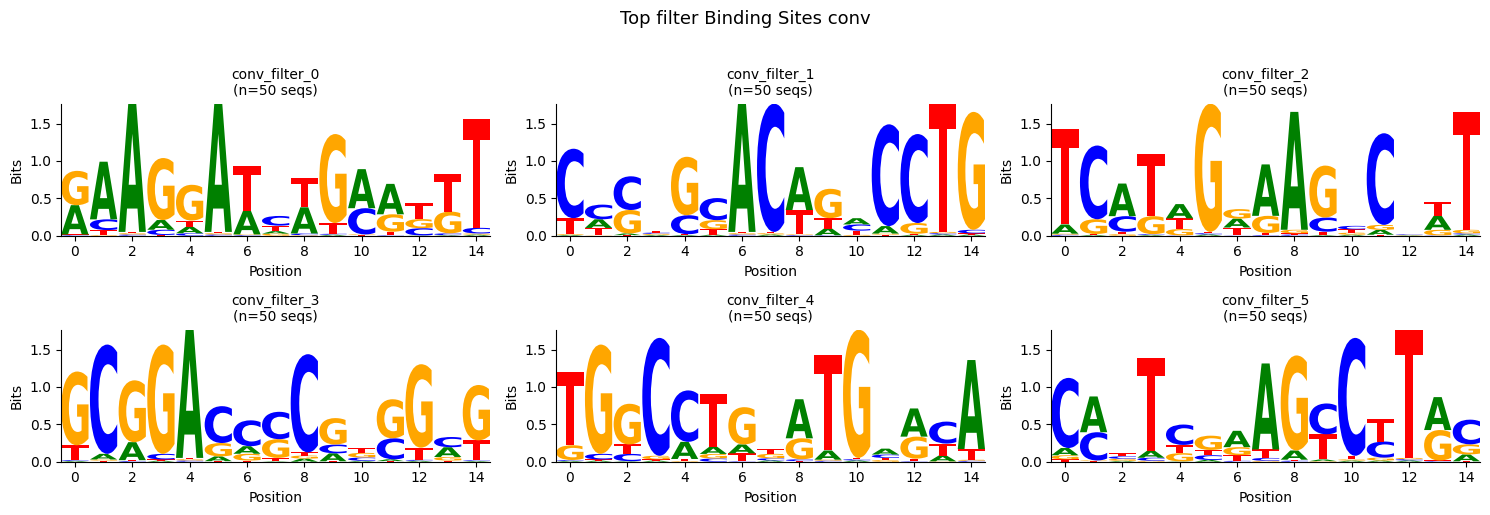

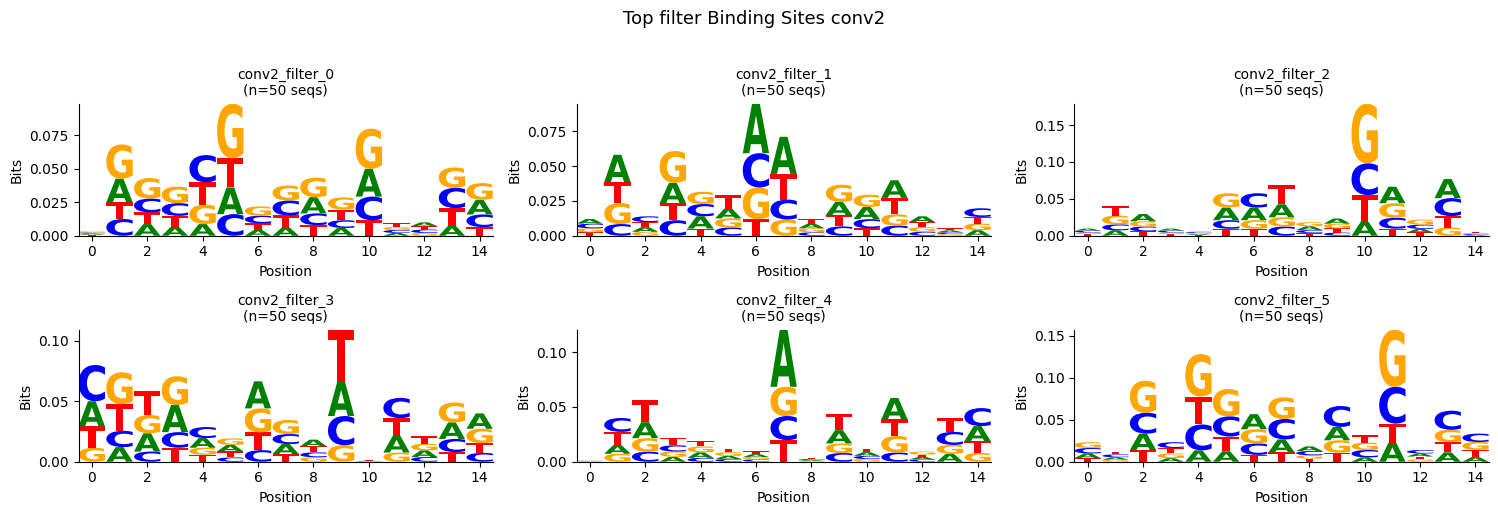

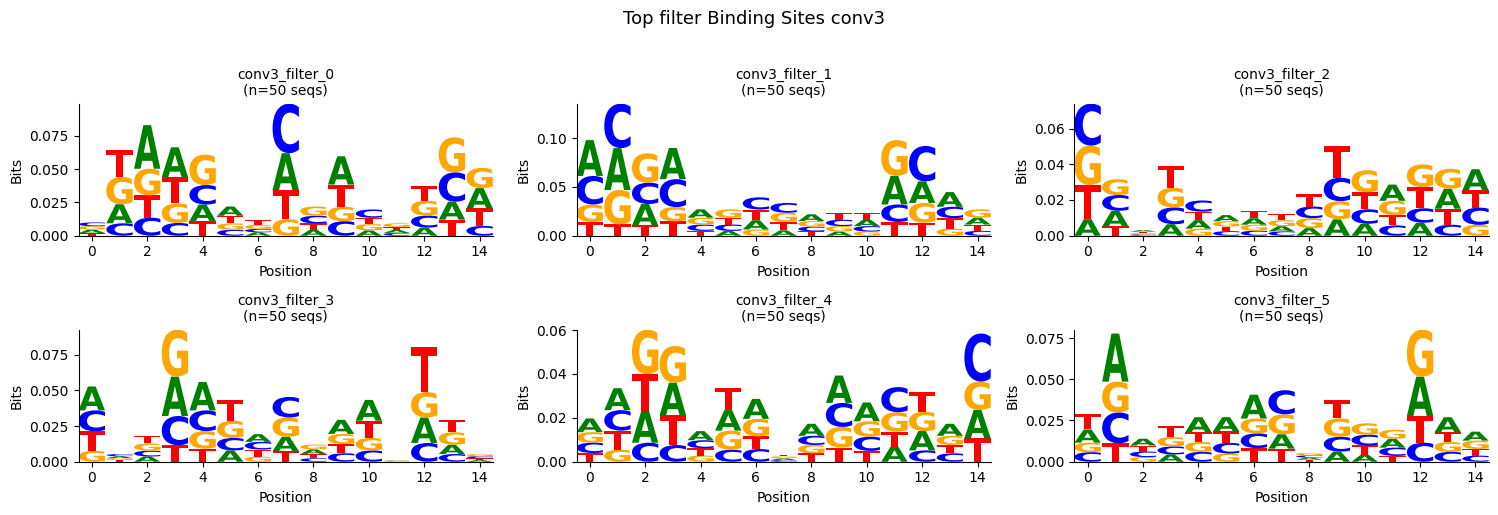

In [ ]:
plot_filter_logos(binding_site_dict_o, layer_name='conv', n_filters=6, top_n=50)
plot_filter_logos(binding_site_dict_o, layer_name='conv2', n_filters=6, top_n=50)
plot_filter_logos(binding_site_dict_o, layer_name='conv3', n_filters=6, top_n=50)

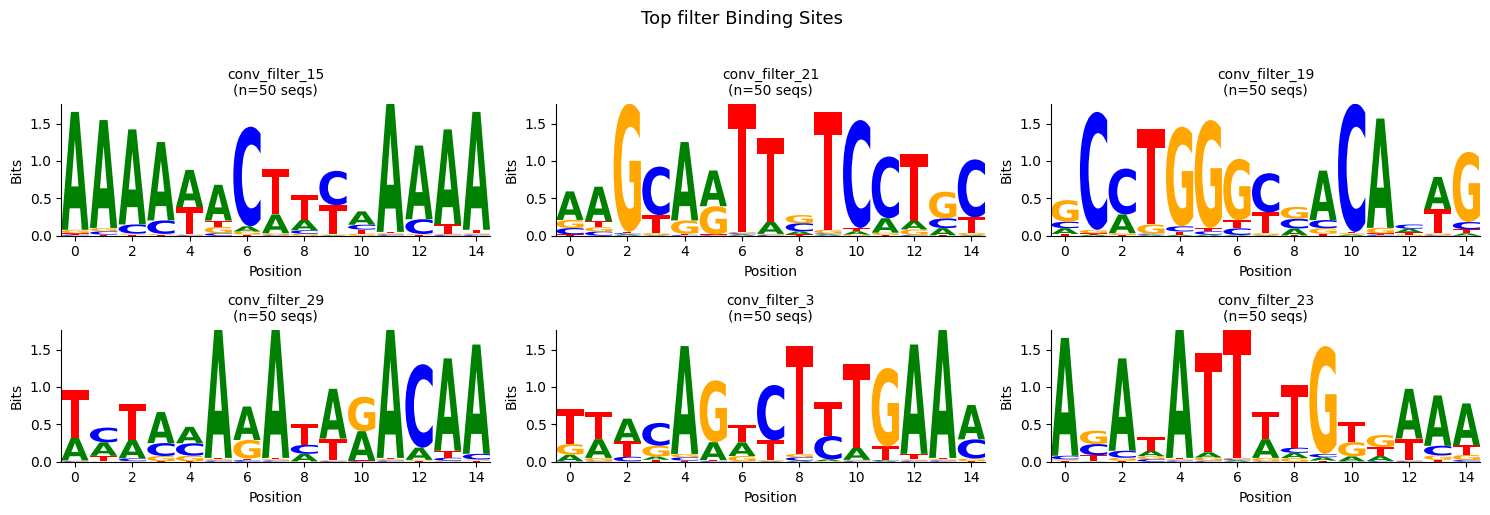

In [ ]:
# Rank all filters by information content and plot the top 6
ranked_o = sorted(binding_site_dict_o.items(),
                  key=lambda x: get_total_information(x[1]),
                  reverse=True)

top_informative_o = dict(ranked[:6])
plot_filter_logos(top_informative_o, layer_name='', n_filters=6, top_n=50)

## Compare Leared Binding Sites Between L1TD1 and ORF1p

In [ ]:
def build_ppm_dict(motif_dict, top_n=50, pseudocount=0.5):
    """
    Convert a motif_dict into a dict of PPMs.
    Filters with fewer than 5 sequences are skipped.
    """
    ppm_dict = {}
    for key, seqs in motif_dict.items():
        seqs = seqs[:top_n]
        if len(seqs) < 5:
            continue
        pfm = seqs_to_pfm(seqs)
        ppm = pfm_to_ppm(pfm, pseudocount=pseudocount)
        ppm_dict[key] = ppm
    return ppm_dict

# Run extraction independently for each dataset/model
# then build PPM dicts
ppm_dict_A = build_ppm_dict(binding_site_dict)  # from L1TD1
ppm_dict_B = build_ppm_dict(binding_site_dict_o)  # from ORF1p

In [ ]:
import numpy as np
from itertools import product

def reverse_complement_ppm(ppm):
    """
    Reverse complement a PPM.
    Columns are [A, C, G, T] so complement swaps A<->T and C<->G,
    then reverse the position order.
    """
    comp_map = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    rc = ppm[['T', 'G', 'C', 'A']].copy()   # complement
    rc.columns = ['A', 'C', 'G', 'T']
    rc = rc.iloc[::-1].reset_index(drop=True) # reverse
    return rc

def pearson_similarity(ppm1, ppm2):
    """
    Pearson correlation between two PPMs flattened to vectors.
    Returns value in [-1, 1]; higher = more similar.
    """
    v1 = ppm1.values.flatten()
    v2 = ppm2.values.flatten()
    if np.std(v1) == 0 or np.std(v2) == 0:
        return 0.0
    return float(np.corrcoef(v1, v2)[0, 1])

def sliding_similarity(ppm1, ppm2, metric_fn=pearson_similarity):
    """
    Slide the shorter PPM across the longer one and take the best score.
    Also checks reverse complement. Returns (best_score, best_offset, rc_flag).
    """
    len1, len2 = len(ppm1), len(ppm2)
    short, long_ = (ppm1, ppm2) if len1 <= len2 else (ppm2, ppm1)
    short_rc     = reverse_complement_ppm(short)

    best_score, best_offset, best_rc = -np.inf, 0, False
    window = len(short)

    for strand, s in [(False, short), (True, short_rc)]:
        for offset in range(len(long_) - window + 1):
            window_ppm = long_.iloc[offset : offset + window].reset_index(drop=True)
            score = metric_fn(s, window_ppm)
            if score > best_score:
                best_score, best_offset, best_rc = score, offset, strand

    return best_score, best_offset, best_rc

In [ ]:
def compare_motif_sets(ppm_dict_A, ppm_dict_B, metric_fn=pearson_similarity):
    """
    Compare every motif in A against every motif in B.
    Returns a DataFrame of shape (len_A, len_B) with similarity scores.
    """
    keys_A = list(ppm_dict_A.keys())
    keys_B = list(ppm_dict_B.keys())

    sim_matrix = pd.DataFrame(index=keys_A, columns=keys_B, dtype=float)

    for kA, kB in product(keys_A, keys_B):
        score, _, _ = sliding_similarity(ppm_dict_A[kA], ppm_dict_B[kB], metric_fn)
        sim_matrix.loc[kA, kB] = score

    return sim_matrix

sim_matrix = compare_motif_sets(ppm_dict_A, ppm_dict_B)

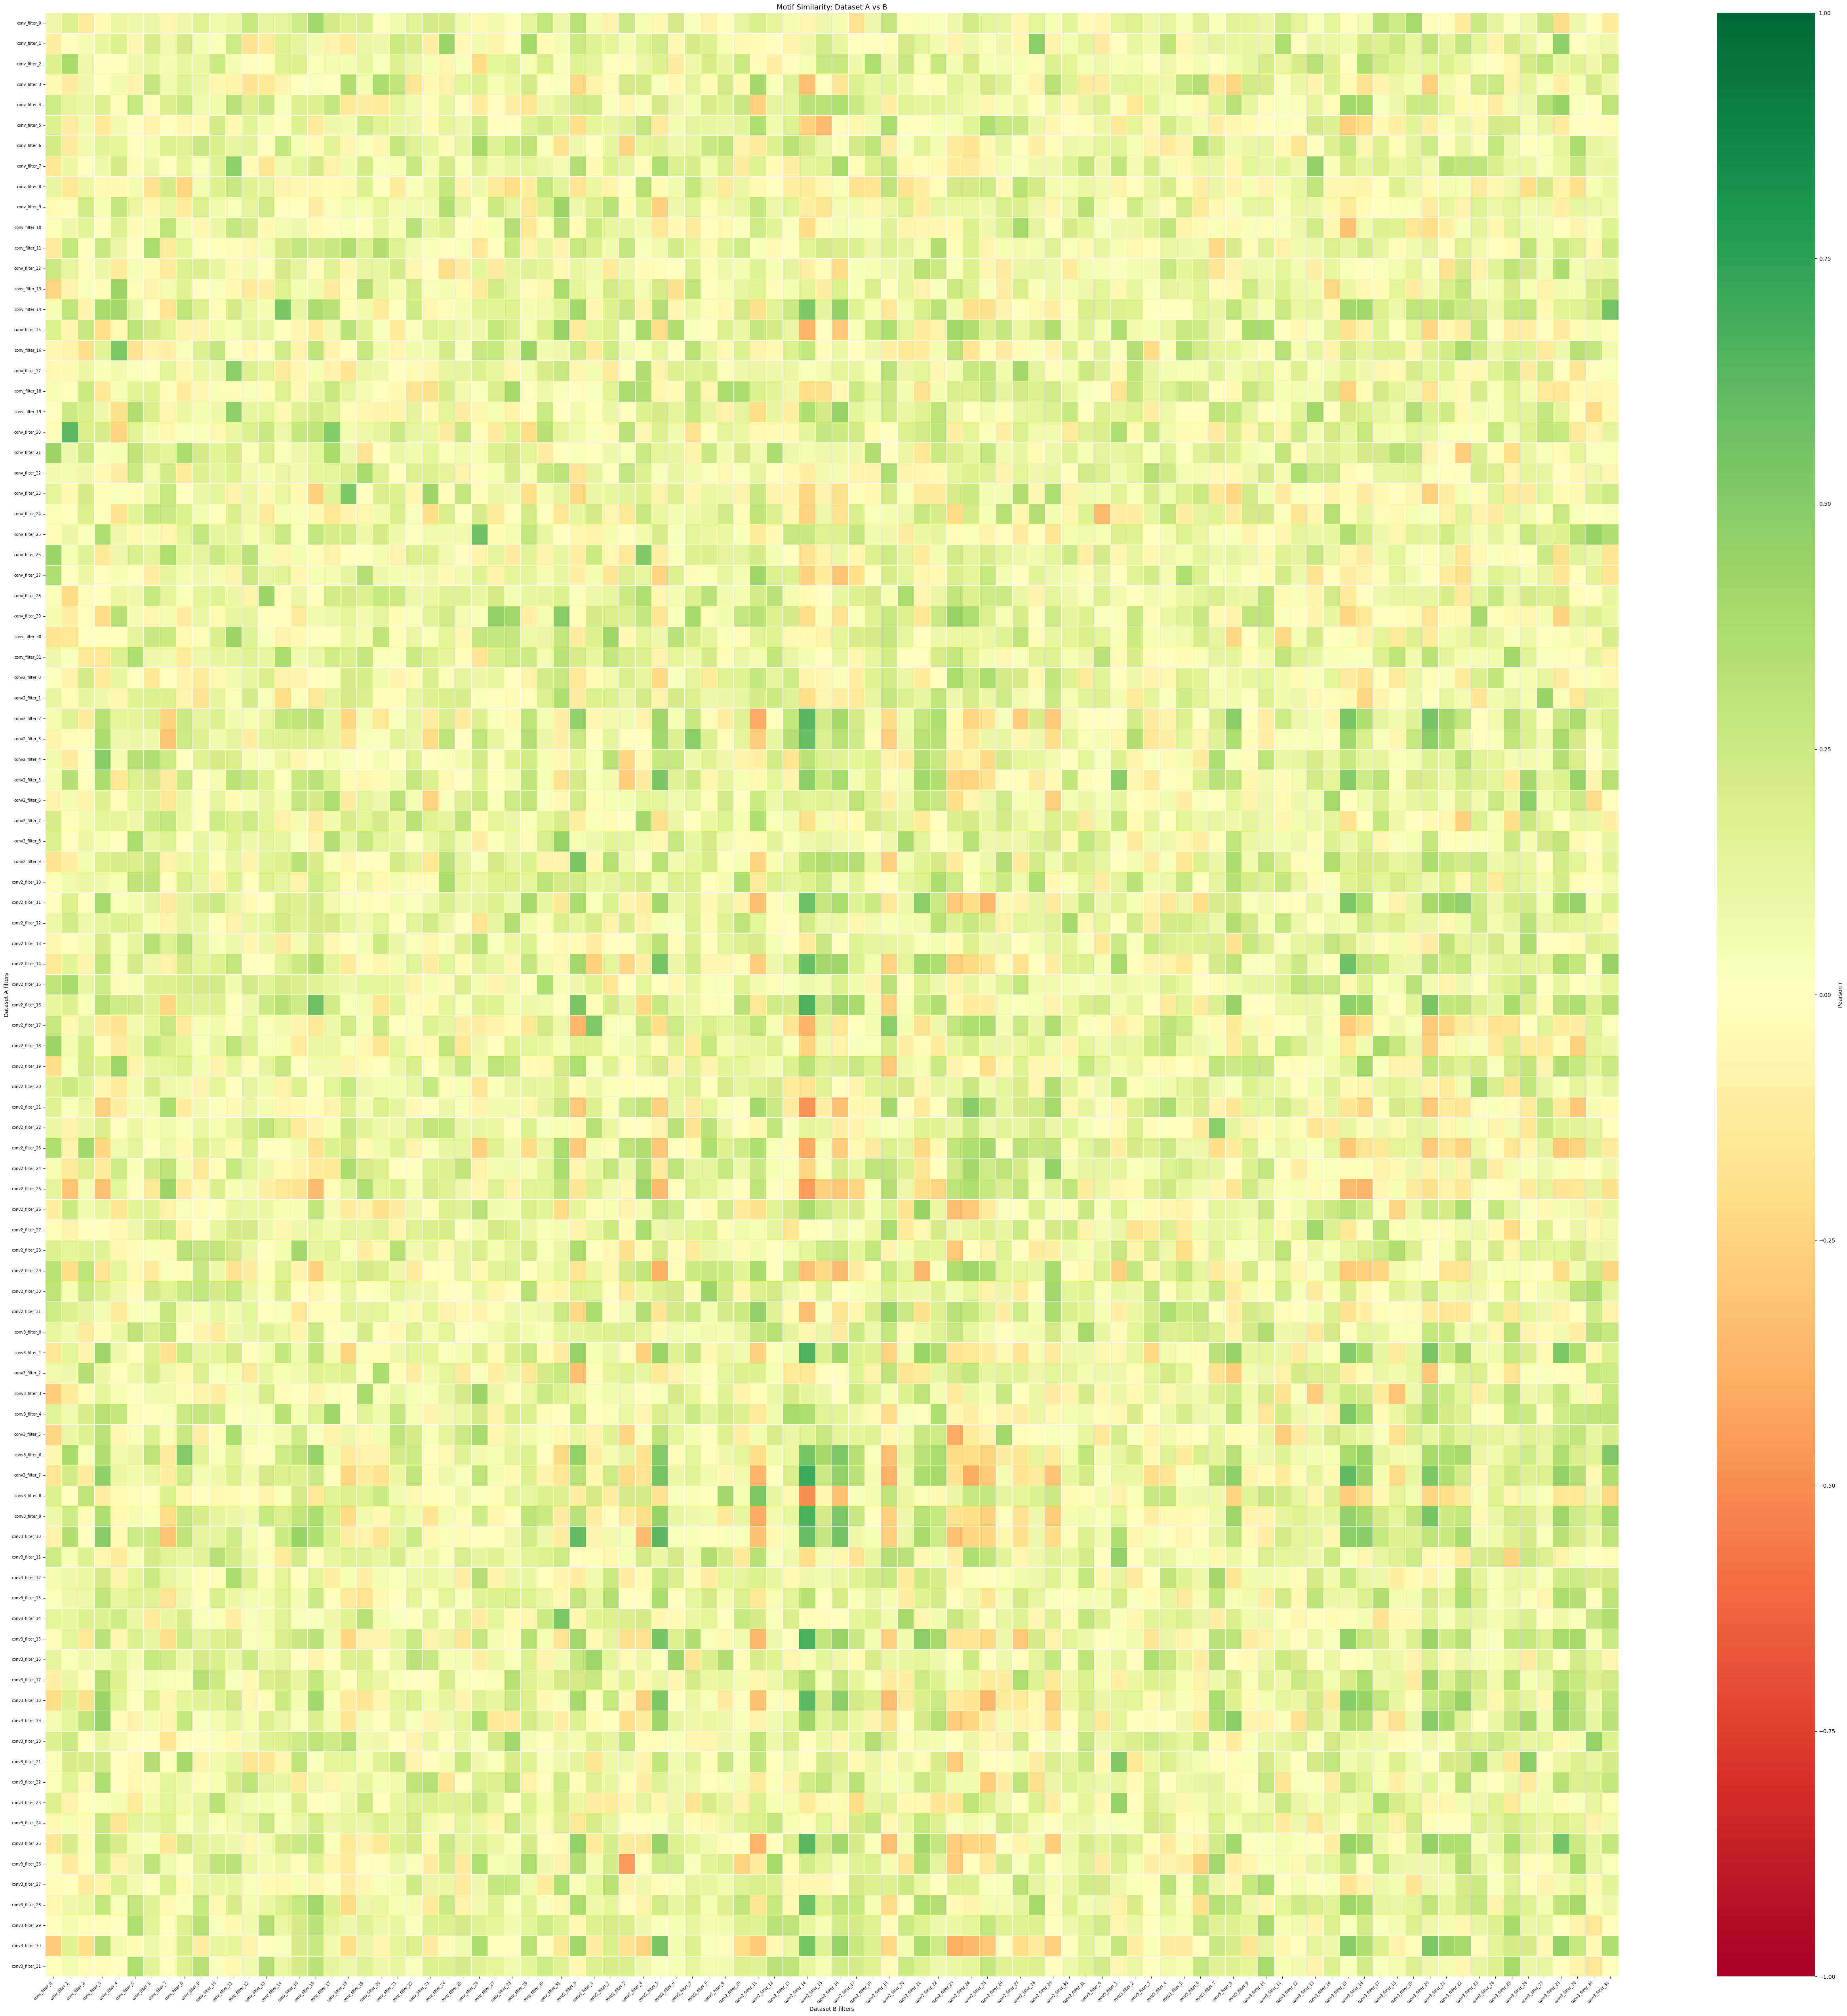

In [ ]:
import seaborn as sns

def plot_similarity_heatmap(sim_matrix, title="Motif Similarity: Dataset A vs B"):
    fig, ax = plt.subplots(figsize=(len(sim_matrix.columns) * 0.5 + 3,
                                    len(sim_matrix.index)  * 0.5 + 3))
    sns.heatmap(
        sim_matrix.astype(float),
        ax=ax,
        cmap='RdYlGn',
        vmin=-1, vmax=1,
        center=0,
        linewidths=0.4,
        annot=len(sim_matrix) <= 20,   # only annotate if small enough
        fmt='.2f',
        cbar_kws={'label': 'Pearson r'}
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Dataset B filters")
    ax.set_ylabel("Dataset A filters")
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()

plot_similarity_heatmap(sim_matrix)

10 with a threshold > 0.6


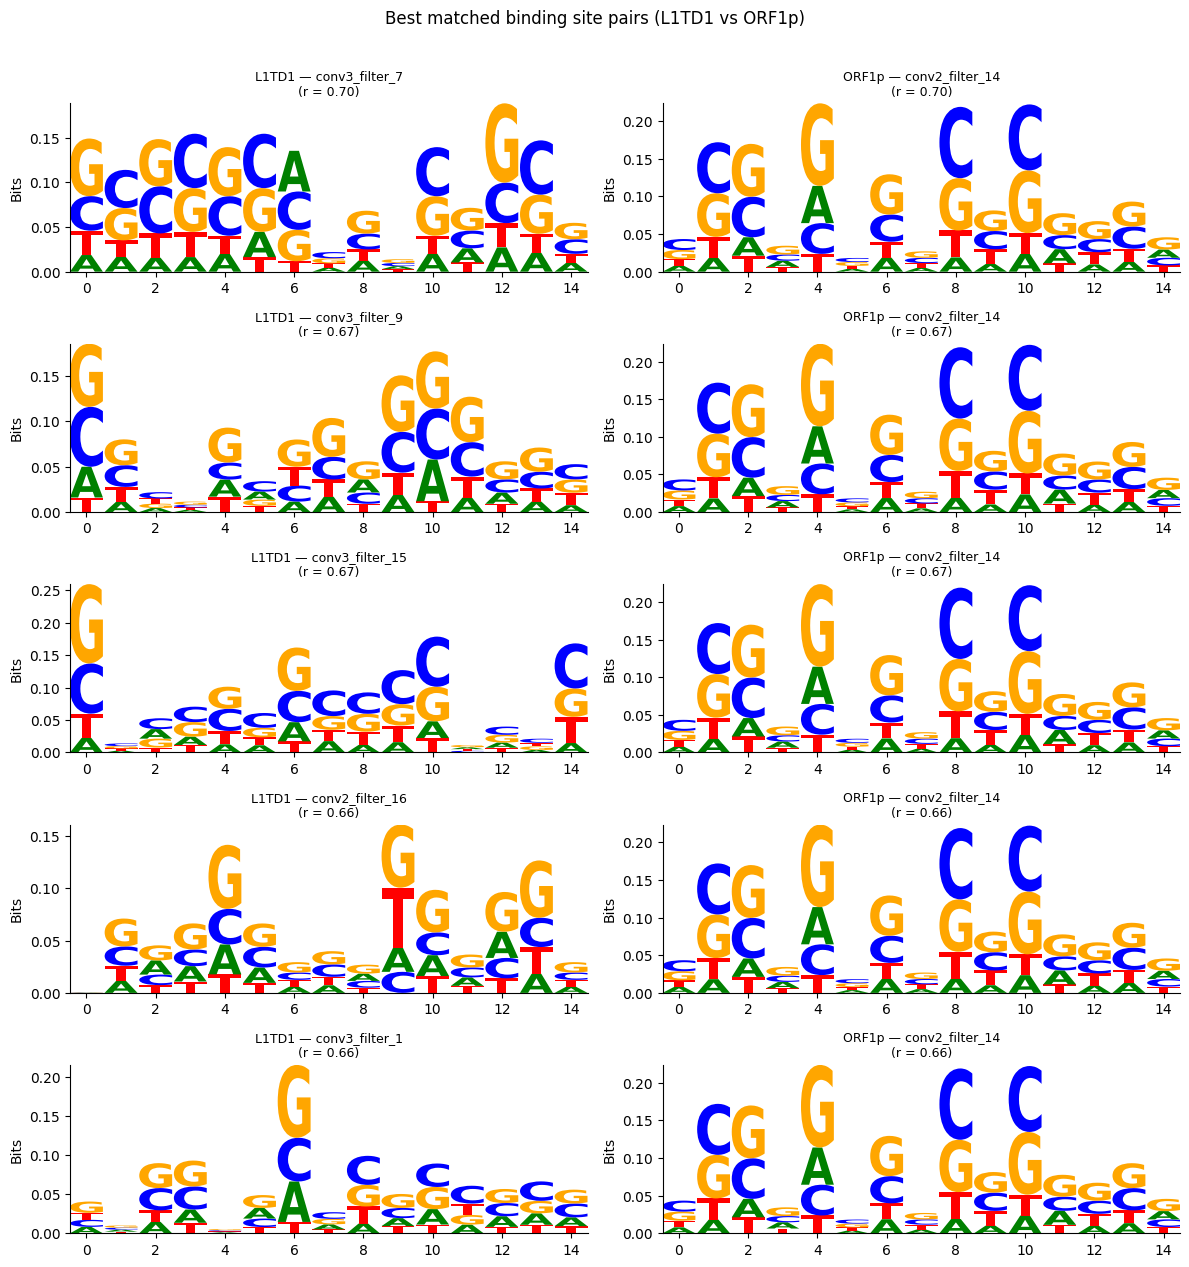

In [ ]:
def get_best_matches(sim_matrix, top_n=5, threshold=0.7):
    """Return the top_n most similar motif pairs above a threshold."""
    pairs = []
    for kA in sim_matrix.index:
        best_kB = sim_matrix.loc[kA].astype(float).idxmax()
        best_score = sim_matrix.loc[kA, best_kB]
        if best_score >= threshold:
            pairs.append((kA, best_kB, best_score))

    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs


def plot_matched_pairs(pairs, ppm_dict_A, ppm_dict_B, label_A='L1TD1', label_B='ORF1p', top_n=5):
    """Plot side-by-side logos for each matched pair."""
    pairs = pairs[: top_n]
    n = len(pairs)
    if n == 0:
        print("No pairs above threshold.")
        return

    fig, axes = plt.subplots(n, 2, figsize=(12, n * 2.5))
    if n == 1:
        axes = [axes]   # keep consistent indexing

    for ax_row, (kA, kB, score) in zip(axes, pairs):
        for ax, key, ppm_dict, label in [
            (ax_row[0], kA, ppm_dict_A, label_A),
            (ax_row[1], kB, ppm_dict_B, label_B)
        ]:
            ppm = ppm_dict[key]
            ic  = logomaker.transform_matrix(ppm, from_type='probability',
                                             to_type='information')
            logomaker.Logo(ic, ax=ax, color_scheme='classic')
            ax.set_title(f"{label} — {key}\n(r = {score:.2f})", fontsize=9)
            ax.set_ylabel("Bits")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    plt.suptitle(f"Best matched binding site pairs ({label_A} vs {label_B})",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


# --- Usage ---
threshold = 0.6
pairs = get_best_matches(sim_matrix, top_n=5, threshold=threshold)
print(f"{len(pairs)} with a threshold > {threshold}")
plot_matched_pairs(pairs, ppm_dict_A, ppm_dict_B)

In [ ]:
def get_pair_sequences(pairs, motif_dict_A, motif_dict_B, top_n=50):
    """
    For each matched pair, retrieve the top_n motif sequences from both datasets.

    Returns a list of dicts with keys: kA, kB, score, seqs_A, seqs_B
    """
    results = []
    for pair in pairs:
        kA, kB, score = pair[0], pair[1], pair[2]  # safe for both Option A and B output

        seqs_A = motif_dict_A.get(kA, [])[:top_n]
        seqs_B = motif_dict_B.get(kB, [])[:top_n]

        results.append({
            'kA':    kA,
            'kB':    kB,
            'score': score,
            'seqs_A': seqs_A,
            'seqs_B': seqs_B,
        })

    return results


pair_sequences = get_pair_sequences(pairs, binding_site_dict, binding_site_dict_o, top_n=1)

# Inspect a pair
for p in pair_sequences:
    print(f"\n{p['kA']} <-> {p['kB']}  (r = {p['score']:.2f})")
    print(f"  L1TD1 seqs ({len(p['seqs_A'])}): {p['seqs_A'][:5]}")
    print(f"  ORF1p seqs ({len(p['seqs_B'])}): {p['seqs_B'][:5]}")


conv3_filter_7 <-> conv2_filter_14  (r = 0.70)
  L1TD1 seqs (1): ['GCCAGCACAACACAG']
  ORF1p seqs (1): ['AGGGTCGGCGGGGGC']

conv3_filter_9 <-> conv2_filter_14  (r = 0.67)
  L1TD1 seqs (1): ['GCAGAAGCTGCTGGT']
  ORF1p seqs (1): ['AGGGTCGGCGGGGGC']

conv3_filter_15 <-> conv2_filter_14  (r = 0.67)
  L1TD1 seqs (1): ['CAATCGGGGGGCATC']
  ORF1p seqs (1): ['AGGGTCGGCGGGGGC']

conv2_filter_16 <-> conv2_filter_14  (r = 0.66)
  L1TD1 seqs (1): ['GGGGCGGGGGCGCCG']
  ORF1p seqs (1): ['AGGGTCGGCGGGGGC']

conv3_filter_1 <-> conv2_filter_14  (r = 0.66)
  L1TD1 seqs (1): ['AGCGTCGCCGCCGGC']
  ORF1p seqs (1): ['AGGGTCGGCGGGGGC']

conv2_filter_2 <-> conv2_filter_14  (r = 0.64)
  L1TD1 seqs (1): ['TAAAAACATTTATTC']
  ORF1p seqs (1): ['AGGGTCGGCGGGGGC']

conv3_filter_10 <-> conv2_filter_5  (r = 0.63)
  L1TD1 seqs (1): ['TGAAAAGGCCCTGTT']
  ORF1p seqs (1): ['GTGCAGAAGATCTTC']

conv3_filter_25 <-> conv2_filter_14  (r = 0.63)
  L1TD1 seqs (1): ['TGAGAGACTGGAGGA']
  ORF1p seqs (1): ['AGGGTCGGCGGGGGC']

conv